### **Dataset**

**Link On Kaggle** : https://www.kaggle.com/datasets/puneet6060/intel-image-classification

#### **📌 Dataset Size**

| Attribute             | Description                                               |
| --------------------- | --------------------------------------------------------- |
| **Dataset Name**      | **Intel Image Classification**                            |
| **Total Images**      | **25,000** (approx.)                                      |
| **Training Images**   | **14,034**                                                |
| **Testing Images**    | **3,000**                                                 |
| **Validation Images** | **7301**                                                  |
| **Number of Classes** | **6** (Buildings, Forest, Glacier, Mountain, Sea, Street) |
| **Data Format**       | **JPEG Images**                                           |

---


### **Importing Libraries**


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(style="whitegrid")
import os
import glob as gb
import cv2
import tensorflow as tf
import keras
from tqdm import tqdm

### **Open Folders**


##### **seg_train**


In [23]:
trainpath = r"G:\Hesham_DL\Image Classification Codes\Data\seg_train\seg_train"

for folder in os.listdir(trainpath):
    files = gb.glob(os.path.join(trainpath, folder, '*.jpg'))
    print(f'Found {len(files)} images in folder: {folder}')

Found 2191 images in folder: buildings
Found 2271 images in folder: forest
Found 2404 images in folder: glacier
Found 2512 images in folder: mountain
Found 2274 images in folder: sea
Found 2382 images in folder: street


##### **seg_test**


In [24]:
testpath = r"G:\Hesham_DL\Image Classification Codes\Data\seg_test\seg_test"

for folder in os.listdir(testpath):
    files = gb.glob(os.path.join(testpath, folder, '*.jpg'))
    print(f'Found {len(files)} images in folder: {folder}')

Found 437 images in folder: buildings
Found 474 images in folder: forest
Found 553 images in folder: glacier
Found 525 images in folder: mountain
Found 510 images in folder: sea
Found 501 images in folder: street


##### **seg_pred**


In [25]:
predpath = r"G:\Hesham_DL\Image Classification Codes\Data\seg_pred"

for folder in os.listdir(predpath):
    files = gb.glob(os.path.join(predpath, folder, '*.jpg'))
    print(f'Found {len(files)} images in folder: {folder}')

Found 7301 images in folder: seg_pred


### **Display Images Sizes**


##### **Images Size For Train Data**


In [26]:
# List to store image sizes
size = []
# Loop through each category folder and read image sizes
for folder in os.listdir(trainpath):
    folder_path = os.path.join(trainpath, folder)
    files = gb.glob(os.path.join(folder_path, '*.jpg'))

    for file in files:
        image = plt.imread(file)
        size.append(image.shape)

# Display unique image sizes
pd.Series(size).value_counts()

(150, 150, 3)    13986
(113, 150, 3)        7
(135, 150, 3)        3
(111, 150, 3)        3
(108, 150, 3)        2
(136, 150, 3)        2
(143, 150, 3)        2
(146, 150, 3)        2
(123, 150, 3)        2
(142, 150, 3)        2
(134, 150, 3)        2
(144, 150, 3)        2
(115, 150, 3)        1
(124, 150, 3)        1
(133, 150, 3)        1
(120, 150, 3)        1
(149, 150, 3)        1
(110, 150, 3)        1
(105, 150, 3)        1
(119, 150, 3)        1
(102, 150, 3)        1
(76, 150, 3)         1
(97, 150, 3)         1
(103, 150, 3)        1
(100, 150, 3)        1
(141, 150, 3)        1
(145, 150, 3)        1
(81, 150, 3)         1
(147, 150, 3)        1
(131, 150, 3)        1
(140, 150, 3)        1
Name: count, dtype: int64

##### **Images Size For Test Data**


In [27]:
# List to store image sizes
size = []
# Loop through each category folder and read image sizes
for folder in os.listdir(testpath):
    folder_path = os.path.join(testpath, folder)
    files = gb.glob(os.path.join(folder_path, '*.jpg'))

    for file in files:
        image = plt.imread(file)
        size.append(image.shape)

# Display unique image sizes
pd.Series(size).value_counts()

(150, 150, 3)    2993
(141, 150, 3)       1
(110, 150, 3)       1
(76, 150, 3)        1
(149, 150, 3)       1
(72, 150, 3)        1
(131, 150, 3)       1
(81, 150, 3)        1
Name: count, dtype: int64

##### **Images Size For Prediction Data**


In [28]:
# List to store image sizes
size = []
# Loop through each category folder and read image sizes
for folder in os.listdir(predpath):
    folder_path = os.path.join(predpath, folder)
    files = gb.glob(os.path.join(folder_path, '*.jpg'))

    for file in files:
        image = plt.imread(file)
        size.append(image.shape)

# Display unique image sizes
pd.Series(size).value_counts()

(150, 150, 3)    7288
(133, 150, 3)       1
(139, 150, 3)       1
(108, 150, 3)       1
(124, 150, 3)       1
(131, 150, 3)       1
(144, 150, 3)       1
(149, 150, 3)       1
(143, 150, 3)       1
(129, 150, 3)       1
(100, 150, 3)       1
(112, 150, 3)       1
(126, 150, 3)       1
(374, 500, 3)       1
Name: count, dtype: int64

### **Reading Images**


In [29]:
# Define image size (width, height)
IMG_SIZE = 64

# Define class-to-number mapping
label = {'buildings': 0, 'forest': 1, 'glacier': 2,
         'mountain': 3, 'sea': 4, 'street': 5}

##### **Train Images**


In [30]:
# Initialize lists for images and labels
X_train = []
y_train = []

# Loop through each folder
for folder in os.listdir(trainpath):
    folder_path = os.path.join(trainpath, folder)
    files = gb.glob(os.path.join(folder_path, '*.jpg'))

    # Loop through each image in the folder
    for file in files:
        img = cv2.imread(file)  # Read the image
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # Resize to fixed size
        X_train.append(img)                          # Append image array
        # Append corresponding label
        y_train.append(label[folder])

# Convert lists to numpy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)

print("✅ Training data loaded successfully!\n")
print(f"X_train shape: {X_train.shape}\n")
print(f"y_train shape: {y_train.shape}")

✅ Training data loaded successfully!

X_train shape: (14034, 64, 64, 3)

y_train shape: (14034,)


#### **Display Some of Training Images**


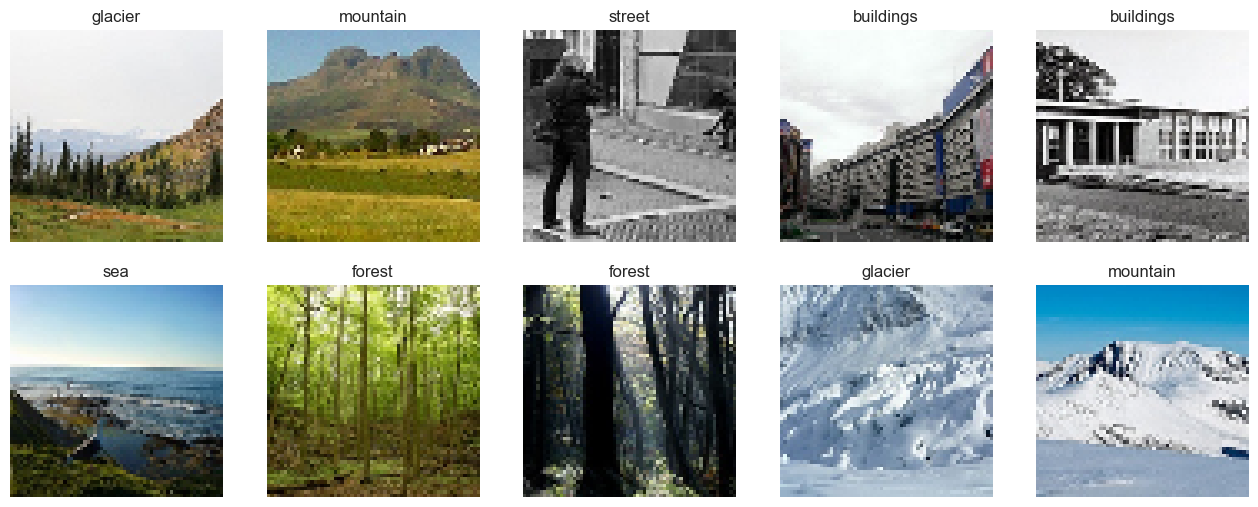

In [31]:
def getcode(y):                  # To get label name from its numeric code
    for k, v in label.items():
        if v == y:
            return k


plt.figure(figsize=(16, 16))
for n, i in enumerate(np.random.randint(0, len(X_train), 10)):
    plt.subplot(5, 5, n + 1)
    # convert BGR → RGB for correct colors
    plt.imshow(cv2.cvtColor(X_train[i], cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(getcode(y_train[i]))

plt.show()

#### **Test Images**


In [32]:
# Initialize lists for images and labels
X_test = []
y_test = []

# Loop through each folder (category)
for folder in os.listdir(testpath):
    folder_path = os.path.join(testpath, folder)
    files = gb.glob(os.path.join(folder_path, '*.jpg'))

    # Loop through each image in the folder
    for file in files:
        img = cv2.imread(file)                       # Read the image
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # Resize to fixed size
        X_test.append(img)                           # Append image array
        # Append corresponding label
        y_test.append(label[folder])

# Convert lists to numpy arrays
X_test = np.array(X_test)
y_test = np.array(y_test)

print("✅ Testing data loaded successfully!\n")
print(f"X_test shape: {X_test.shape}\n")
print(f"y_test shape: {y_test.shape}")

✅ Testing data loaded successfully!

X_test shape: (3000, 64, 64, 3)

y_test shape: (3000,)


### **Display Some of Test Images**


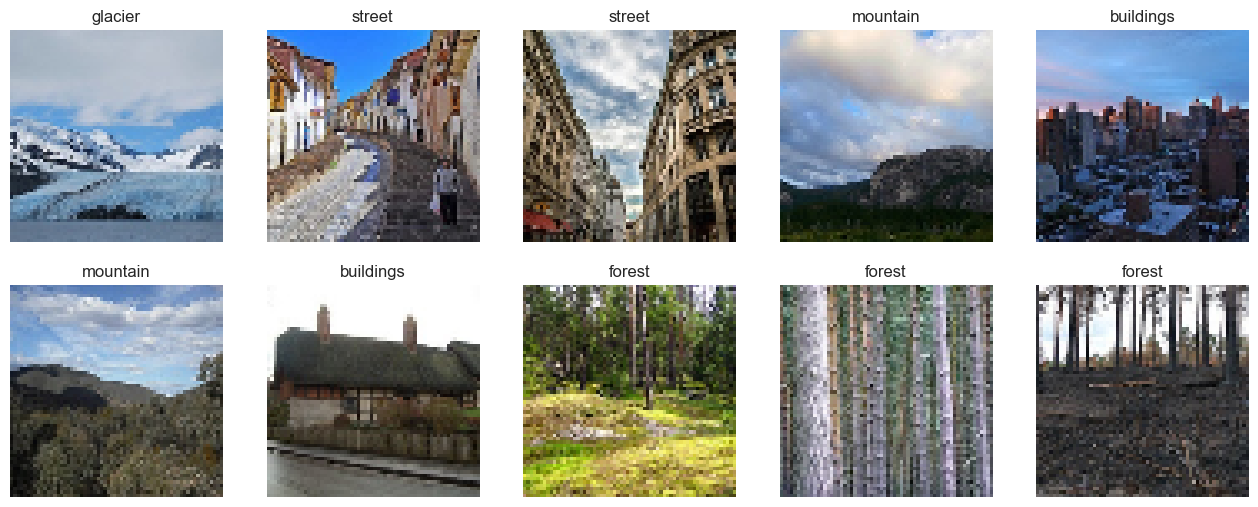

In [33]:
# Display 36 random images with their labels
plt.figure(figsize=(16, 16))
for n, i in enumerate(np.random.randint(0, len(X_test), 10)):
    plt.subplot(5, 5, n + 1)
    # convert BGR → RGB for correct colors
    plt.imshow(cv2.cvtColor(X_test[i], cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(getcode(y_test[i]))

plt.show()

#### **Prediction Images**


In [34]:
# Initialize lists for images and labels
X_pred = []

# Loop through each folder (category)
for folder in os.listdir(predpath):
    folder_path = os.path.join(predpath, folder)
    files = gb.glob(os.path.join(folder_path, '*.jpg'))

    # Loop through each image in the folder
    for file in files:
        img = cv2.imread(file)                       # Read the image
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # Resize to fixed size
        X_pred.append(img)                           # Append image array


# Convert lists to numpy arrays
X_pred = np.array(X_pred)


print("✅ Prediction data loaded successfully!\n")
print(f"X_pred shape: {X_pred.shape}\n")

✅ Prediction data loaded successfully!

X_pred shape: (7301, 64, 64, 3)



### **Display Some of Prediction Images**


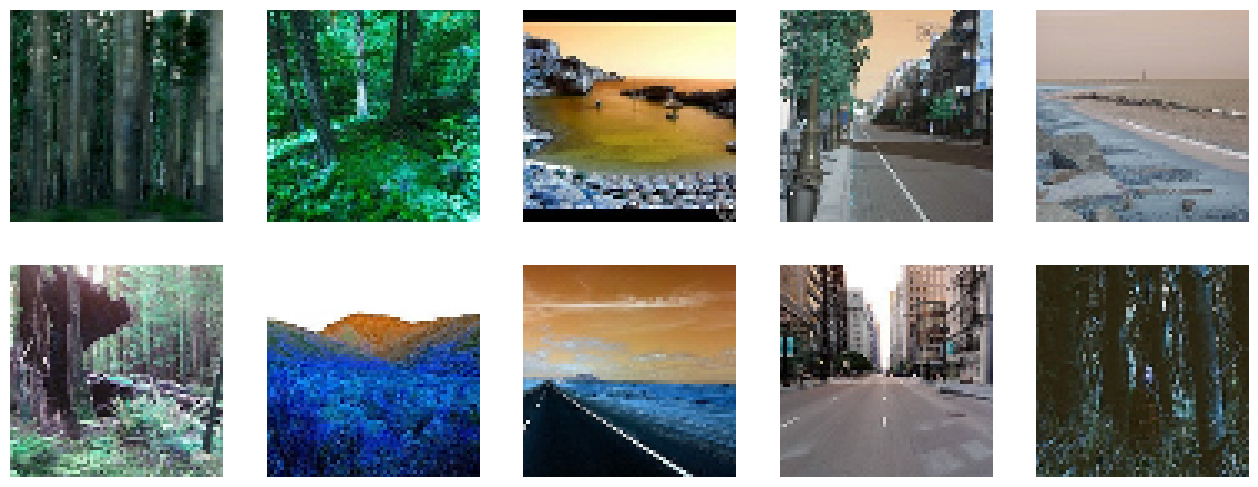

In [35]:
# Display 36 random images with their labels
plt.figure(figsize=(16, 16))
for n, i in enumerate(np.random.randint(0, len(X_pred), 10)):
    plt.subplot(5, 5, n + 1)
    plt.imshow(X_pred[i])
    plt.axis('off')

plt.show()

### **Building The CNN Model**


In [36]:
print('X Train Shape is : ', X_train.shape)
print('y Train Shape is : ', y_train.shape)  # Photo size 28x28
print("="*36)
print('X Test Shape is : ', X_test.shape)
print('y Test Shape is : ', y_test.shape)
print("="*36)
print('X_pred Shape is : ', X_pred.shape)

X Train Shape is :  (14034, 64, 64, 3)
y Train Shape is :  (14034,)
X Test Shape is :  (3000, 64, 64, 3)
y Test Shape is :  (3000,)
X_pred Shape is :  (7301, 64, 64, 3)


In [37]:
X_train = X_train / 255.0
X_test = X_test / 255.0
X_pred = X_pred / 255.0

In [38]:
model = keras.models.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu',
                        input_shape=(64, 64, 3)),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(2, 2),

    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(2, 2),

    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(2, 2),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(6, activation='softmax')
])

c:\envs\torch311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [ ]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1,
                    callbacks=[tf.keras.callbacks.EarlyStopping(patience=20, monitor='val_accuracy', restore_best_weights=True)])

Epoch 1/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 65s 141ms/step - accuracy: 0.5795 - loss: 1.2022 - val_accuracy: 0.4953 - val_loss: 1.5372
Epoch 2/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 54s 122ms/step - accuracy: 0.6932 - loss: 0.8560 - val_accuracy: 0.6953 - val_loss: 0.8171
Epoch 3/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 48s 110ms/step - accuracy: 0.7344 - loss: 0.7504 - val_accuracy: 0.6350 - val_loss: 1.1194
Epoch 4/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 63s 143ms/step - accuracy: 0.7639 - loss: 0.6720 - val_accuracy: 0.6397 - val_loss: 1.0449
Epoch 5/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 64s 145ms/step - accuracy: 0.7842 - loss: 0.6132 - val_accuracy: 0.6240 - val_loss: 1.3896
Epoch 6/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 54s 124ms/step - accuracy: 0.8021 - loss: 0.5668 - val_accuracy: 0.7377 - val_loss: 0.7004
Epoch 7/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 55s 126ms/step - accuracy: 0.8171 - loss: 0.5193 - val_accuracy: 0.6473 - val_loss: 1.4336
Epoch 8/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 54s 122ms/step - accuracy: 0.8335 - loss: 0

In [41]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,053,716 (7.83 MB)

 Trainable params: 684,422 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 1,368,846 (5.22 MB)

### **Saving Model**


In [43]:
model.save('CNN.model.keras')

In [44]:
CNN_Model = keras.models.load_model('CNN.model.keras')

In [45]:
y_pred = CNN_Model.predict(X_test)
print('Prediction Shape is {}'.format(y_pred.shape))

94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step
Prediction Shape is (3000, 6)


In [46]:
y_pred = np.argmax(y_pred, axis=1)

In [49]:
# Print the first few predictions vs actual labels
print("Predicted labels: ", y_pred[:20])
print("True labels:      ", y_test[:20])

Predicted labels:  [0 5 5 0 3 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
True labels:       [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### **Evaluation**


In [50]:
ModelLoss, ModelAccuracy = CNN_Model.evaluate(X_test, y_test)
print('Model Loss is {}'.format(ModelLoss))
print('Model Accuracy is {}'.format(ModelAccuracy))

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8317 - loss: 0.6095
Model Loss is 0.6095010042190552
Model Accuracy is 0.8316666483879089


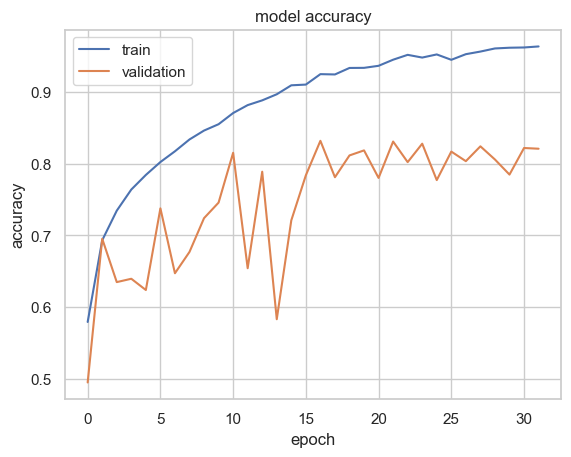

In [51]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

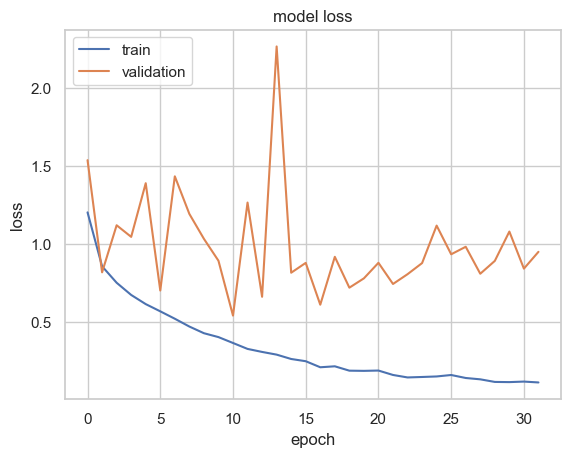

In [52]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

### **Prediction**


In [53]:
y_result = CNN_Model.predict(X_pred)

229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step


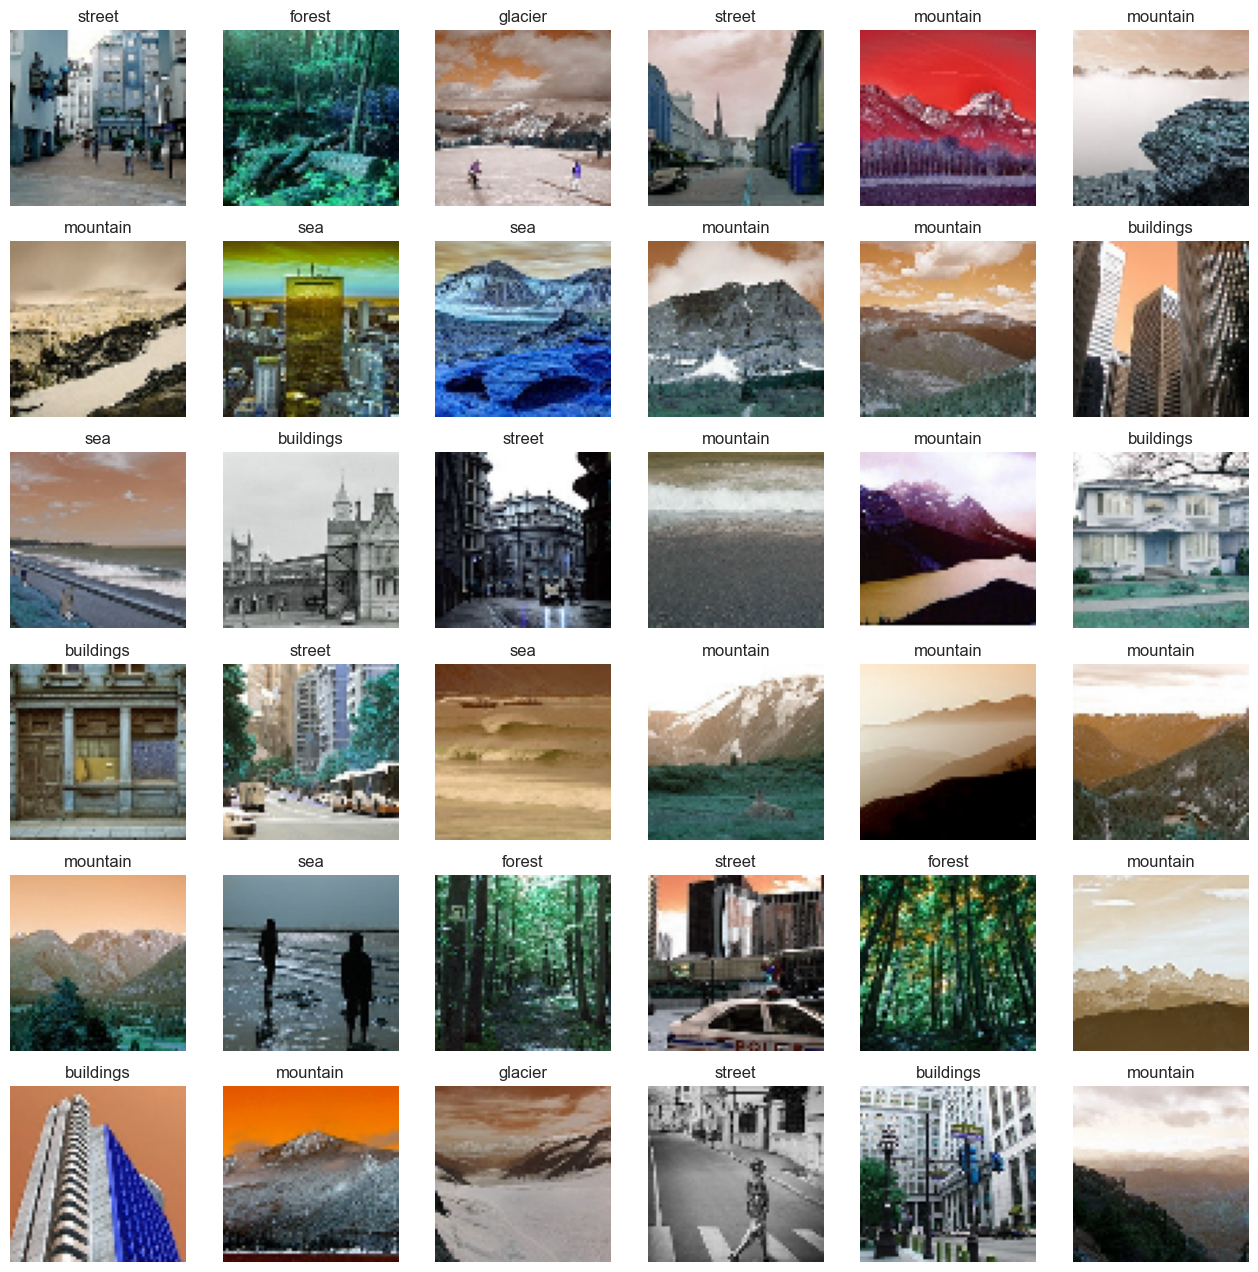

In [55]:
# Display 36 random images with their labels
plt.figure(figsize=(16, 16))
for n, i in enumerate(np.random.randint(0, len(X_pred), 36)):
    plt.subplot(6, 6, n + 1)
    plt.imshow((X_pred[i]))
    plt.axis('off')
    plt.title(getcode(np.argmax(y_result[i])))

plt.show()